# Setup

In [58]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import time
import pandas as pd


torch.manual_seed(42)

def select_device():
    if torch.cuda.is_available():
        device = "cuda"
    elif torch.mps.is_available():
        device = "mps"
    else:
        device = "cpu"
    return torch.device(device)

device = select_device()


In [32]:
transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Task1

In [33]:
B, d = 8, 5

x = torch.randn(B, d)

bn = nn.BatchNorm1d(d)

bn.train()

# pytorch
y_pytorch = bn(x)

# ręcznie
# dim=0 bo liczymy statystyki wzdłuż batcha dla każdej cechy osobno
batch_mean = x.mean(dim=0)
batch_var = x.var(dim=0, unbiased=False) # unbiased=False, bo inaczej dzieliłoby przez liczbę stoponi swobody

# domyślny eps
eps = bn.eps 

# Normalizacja
x_norm = (x - batch_mean) / torch.sqrt(batch_var + eps)

# bn.weight to gamma, bn.bias to beta
y_manual = bn.weight * x_norm + bn.bias

print(f"Diff train: {torch.max(torch.abs(y_pytorch - y_manual)).item():.10f}")

Diff train: 0.0000001192


In [34]:
# eval
bn.eval()

# pytorch
y_pytorch_eval = bn(x)

# ręcznie
run_mean = bn.running_mean
run_var = bn.running_var

# Zauważ, że tu uzywamy running stats zamiast  i batch_var
y_manual_eval = (x - run_mean) / torch.sqrt(run_var + eps)
y_manual_eval = bn.weight * y_manual_eval + bn.bias

# 3. Weryfikacja
print(f"Diff eval: {torch.max(torch.abs(y_pytorch_eval - y_manual_eval)).item():.10f}")

Diff eval: 0.0000001192


1. what changes between training mode and evaluation mode
    * W trybie train() BatchNorm normalizuje dane używając średniej i wariancji z aktualnego batcha (i po cichu aktualizuje statystyki globalne). 
    * W trybie eval() ignoruje batch i używa zamrożonych statystyk globalnych.

2. what running_mean and running_var represent
    To przybliżenia globalnej średniej i wariancji dla całego zbioru treningowego, uaktualniane płynnie w trakcie treningu za pomocą średniej ruchomej (EMA).

3. why the outputs in train and eval mode are generally different
U nas różnicy nie ma, ale na ogół różnią się, bo w train() dzielimy przez lokalne parametry batcha (które są zaszumione), a w eval() przez sztywne, uśrednione parametry z całego treningu.

4. why this matters during inference
    Gwarantuje to determinizm w odpowiedziach sieci


# Task2

Input shape: $(B, 3, 32, 32)$

Parametry:
(in_channels * kernel_height * kernel_width * out_channels) + out_channels_bias

```python 
nn.Sequential(
    # (B, 3, 32, 32)
    nn.Conv2d(3, 16, kernel_size=3, padding=1), # 3 * 3 * 3 * 16 + 16 = 448
    # (B, 16, 32, 32)
    nn.ReLU(),
    # (B, 16, 32, 32)
    nn.MaxPool2d(kernel_size=2),    # spatial change
    # (B, 16, 16, 16)
    nn.Conv2d(16, 32, kernel_size=3, padding=1), # 16 * 3 * 3 * 32 + 32 = 4640
    # (B, 32, 16, 16)
    nn.BatchNorm2d(32), # 2 * 32 = 64
    # (B, 32, 16, 16)
    nn.ReLU(),
    # (B, 32, 16, 16)
    nn.MaxPool2d(kernel_size=2),    # spatial change
    # (B, 32, 8, 8)
    nn.Flatten(),                   # spatial change
    # (B, 2048)
    nn.Linear(32 * 8 * 8, 10) # 2048 * 10 + 10 = 20490  # spatial change
    # (B, 10)
)
```

Wszystkie parametry: 20490 + 64 + 4640 + 448 = 25642

Warstwy pooling "podsumowują" sąsiadujące piksele w lokalnych oknach (tutaj 2x2), wybierając z nich maximum. 

Skutkuje to zmniejszeniem (downsamplingiem) wymiarów przestrzennych mapy cech, co redukuje koszty obliczeniowe, zmniejsza liczbę parametrów w późniejszych warstwach (zapobiegając overfittingowi), sieć rozpoznaje cechę niezależnie od tego, czy przesunie się ona lekko na obrazku.


1. Why convolution preserves or changes spatial size depending on stride and padding?
    Wszystko zależy od tego jak to się układa geometrycznie. Prosta zależność.

2. Why MaxPool2d(2) reduces the height and width?
    Okienka 2x2 są zmiejszane do 1x1, czyli 4x zmiejsza rozmiar.

3. Why BatchNorm2d(32) does not change the tensor shape?
    BatchNorm to operacja "element-wise" z perspektywy kształtu. Wylicza ona średnią i wariancję wzdłuż wymiaru batcha i wymiarów przestrzennych dla każdego z 32 kanałów osobno, a następnie po prostu zastępuje każdą pierwotną wartość w tensorze jej znormalizowanym odpowiednikiem.

4. Why flattening is needed before the final linear layer?
    Warstwy FC (nn.Linear) operują wyłącznie na jednowymiarowych wektorach cech. Wymagają shape (Batch, Cechy). Ostatnia warstwa konwolucyjna wypluwa dane o kształcie (Batch, Kanały, Wysokość, Szerokość) – to trójwymiarowe mapy. Flatten "rozpłaszcza" te przestrzenne struktury do jednego długiego wektora cech, co pozwala przemnożyć go przez płaską macierz wag warstwy liniowej.

# Task3

In [35]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [42]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [43]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [44]:
model_cnn = SimpleCNN().to(device)

print(model_cnn)

SimpleCNN(
  (net): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=2048, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [45]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nLiczba trenowalnych parametrów w SimpleCNN: {count_parameters(model_cnn):,}")


Liczba trenowalnych parametrów w SimpleCNN: 268,650


In [46]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model_cnn.parameters(), lr=0.01)

In [47]:
epochs = 10
history_cnn = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("\nRozpoczynamy trening SimpleCNN...")
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_cnn, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_cnn, val_loader, criterion, device)

    history_cnn['train_loss'].append(train_loss)
    history_cnn['val_loss'].append(val_loss)
    history_cnn['train_acc'].append(train_acc)
    history_cnn['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


Rozpoczynamy trening SimpleCNN...
Epoch 01/10 | Train Loss: 1.6419 | Train Acc: 0.3984 | Val Loss: 1.4072 | Val Acc: 0.4926
Epoch 02/10 | Train Loss: 1.3323 | Train Acc: 0.5217 | Val Loss: 1.2592 | Val Acc: 0.5528
Epoch 03/10 | Train Loss: 1.2089 | Train Acc: 0.5689 | Val Loss: 1.2033 | Val Acc: 0.5674
Epoch 04/10 | Train Loss: 1.1442 | Train Acc: 0.5951 | Val Loss: 1.2172 | Val Acc: 0.5640
Epoch 05/10 | Train Loss: 1.0956 | Train Acc: 0.6136 | Val Loss: 1.2299 | Val Acc: 0.5702
Epoch 06/10 | Train Loss: 1.0522 | Train Acc: 0.6276 | Val Loss: 1.1709 | Val Acc: 0.5836
Epoch 07/10 | Train Loss: 1.0317 | Train Acc: 0.6345 | Val Loss: 1.2475 | Val Acc: 0.5800
Epoch 08/10 | Train Loss: 0.9960 | Train Acc: 0.6470 | Val Loss: 1.1928 | Val Acc: 0.5850
Epoch 09/10 | Train Loss: 0.9828 | Train Acc: 0.6490 | Val Loss: 1.2514 | Val Acc: 0.5758
Epoch 10/10 | Train Loss: 0.9730 | Train Acc: 0.6528 | Val Loss: 1.1883 | Val Acc: 0.5934


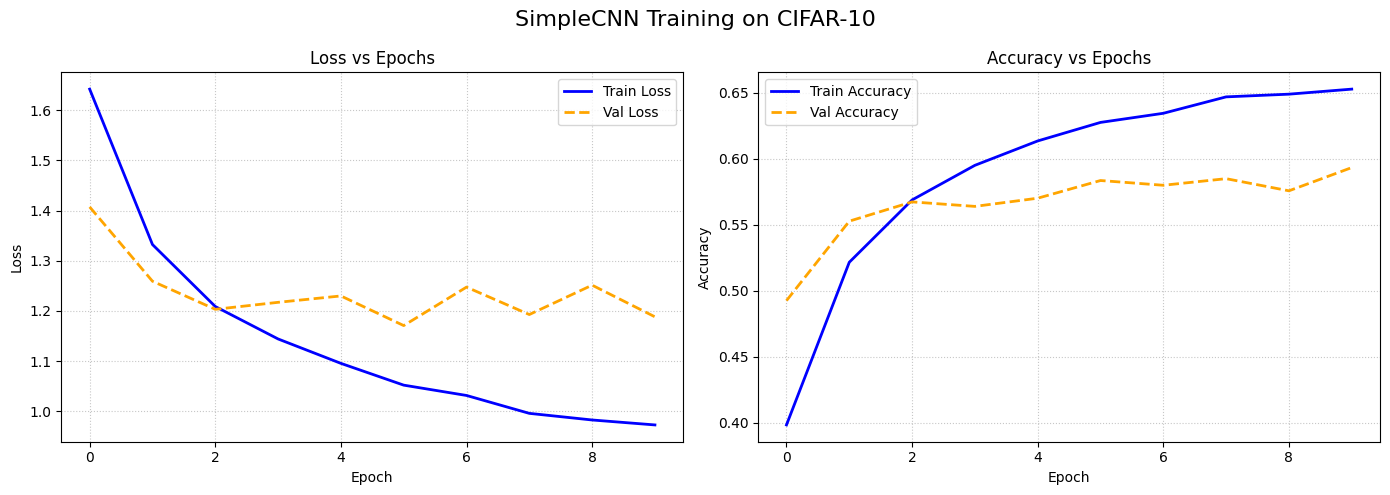

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SimpleCNN Training on CIFAR-10", fontsize=16)

axes[0].plot(history_cnn['train_loss'], label='Train Loss', color='blue', linewidth=2)
axes[0].plot(history_cnn['val_loss'], label='Val Loss', color='orange', linestyle='--', linewidth=2)
axes[0].set_title('Loss vs Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

axes[1].plot(history_cnn['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
axes[1].plot(history_cnn['val_acc'], label='Val Accuracy', color='orange', linestyle='--', linewidth=2)
axes[1].set_title('Accuracy vs Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

1. Why CNNs are more suitable for images than fully-connected networks? 
CNN jest w stanie nauczyć sie wzorców geometrycznych, ponieważ nie czyta obrazku jako jednowymiarowej strukutury, tylko stra się czytać tą strukture własnie dwuwymiarowo. 

2. What local connectivity means?
Pojedynczy neuron w CNN nie jest połączony z każdym pojedynczym pikselem obrazu wejściowego, ale tylko z małym, lokalnym wycinkiem np: 3x3.

3. What weight sharing means?
Oznacza to używanie tego samego zestawu wag (tego samego filtra/jądra splotu) do skanowania całego obrazka poprzez przesuwanie go piksel po pikselu.

4. How pooling changes the representation?
    * Downsampling -  zmniejsza rozdzielczość wymiarów przestrzennych.
    * Podsumowywanie -  zatrzymuje tylko najsilniejsze sygnały, a nie jej idealnie dokładną lokalizację.
    * Kolejne filtry konwolucyjne "widzą" w swoich małych oknach 3x3 znacznie większy fragment oryginalnego, początkowego obrazka.

# Task4

In [53]:
class ModelA(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # (B, 3, 32, 32)
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            # (B, 16, 32, 32)
            nn.ReLU(),
            # (B, 16, 32, 32)
            nn.MaxPool2d(2),
            # (B, 16, 16, 16)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            # (B, 32, 16, 16)
            nn.ReLU(),
            # (B, 32, 16, 16)
            nn.MaxPool2d(2),
            # (B, 32, 8, 8)
            nn.Flatten(),
            # (B, 32 * 8 * 8)
            nn.Linear(32 * 8 * 8, 10)
            # (B, 10)
            
        )
    def forward(self, x): 
        return self.net(x)

class ModelB(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # (B, 3, 32, 32)
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            # (B, 16, 32, 32)
            nn.ReLU(),
            # (B, 16, 32, 32)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            # (B, 32, 32, 32)
            nn.ReLU(),
            # (B, 32, 32, 32)
            nn.Flatten(),
            # (B, 32 * 32 * 32)
            nn.Linear(32 * 32 * 32, 10) 
            # (B, 10)
        )
    def forward(self, x):
        return self.net(x)

class ModelC(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # (B, 3, 32, 32)
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            # (B, 16, 32, 32)
            nn.BatchNorm2d(16),
            # (B, 16, 32, 32)
            nn.ReLU(),
            # (B, 16, 32, 32)
            nn.MaxPool2d(2),
            # (B, 16, 16, 16)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            # (B, 32, 16, 16)
            nn.BatchNorm2d(32),
            # (B, 32, 16, 16)
            nn.ReLU(),
            # (B, 32, 16, 16)
            nn.MaxPool2d(2),
            # (B, 32, 8, 8)
            nn.Flatten(),
            # (B, 32 * 8 * 8)
            nn.Linear(32 * 8 * 8, 10)
            # (B, 10)
        )
    def forward(self, x):
        return self.net(x)

In [62]:
models_dict = {
    "Model A (Baseline)": ModelA().to(device),
    "Model B (No Pool)": ModelB().to(device),
    "Model C (Pool + BN)": ModelC().to(device)
}

epochs = 50
experiment_results = {}
summary_table_data = []

print("Rozpoczynamy eksperyment porównawczy...")

for name, model in models_dict.items():
    print(f"\n--- Trenowanie: {name} ---")
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    start_time = time.time()
    
    for epoch in range(epochs):
        t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)
        
        hist['train_loss'].append(t_loss)
        hist['val_loss'].append(v_loss)
        hist['train_acc'].append(t_acc)
        hist['val_acc'].append(v_acc)
        
        print(f"Epoka {epoch+1}/{epochs} | Train Loss: {t_loss:.4f} | Val Acc: {v_acc:.4f}")
        
    train_time = time.time() - start_time
    experiment_results[name] = hist
    
    summary_table_data.append({
        "Model": name,
        "Pooling": "Yes" if "No Pool" not in name else "No",
        "BatchNorm": "Yes" if "BN" in name else "No",
        "Parameters": count_parameters(model),
        "Final Train Loss": hist['train_loss'][-1],
        "Final Val Loss": hist['val_loss'][-1],
        "Final Train Acc": hist['train_acc'][-1],
        "Final Val Acc": hist['val_acc'][-1],
        "Time (s)": round(train_time, 1)
    })

Rozpoczynamy eksperyment porównawczy...

--- Trenowanie: Model A (Baseline) ---
Epoka 1/50 | Train Loss: 1.6490 | Val Acc: 0.5052
Epoka 2/50 | Train Loss: 1.3396 | Val Acc: 0.5460
Epoka 3/50 | Train Loss: 1.2418 | Val Acc: 0.5560
Epoka 4/50 | Train Loss: 1.1746 | Val Acc: 0.5856
Epoka 5/50 | Train Loss: 1.1162 | Val Acc: 0.6102
Epoka 6/50 | Train Loss: 1.0648 | Val Acc: 0.6338
Epoka 7/50 | Train Loss: 1.0249 | Val Acc: 0.6266
Epoka 8/50 | Train Loss: 0.9840 | Val Acc: 0.6454
Epoka 9/50 | Train Loss: 0.9541 | Val Acc: 0.6526
Epoka 10/50 | Train Loss: 0.9229 | Val Acc: 0.6610
Epoka 11/50 | Train Loss: 0.9045 | Val Acc: 0.6524
Epoka 12/50 | Train Loss: 0.8796 | Val Acc: 0.6720
Epoka 13/50 | Train Loss: 0.8703 | Val Acc: 0.6640
Epoka 14/50 | Train Loss: 0.8490 | Val Acc: 0.6768
Epoka 15/50 | Train Loss: 0.8358 | Val Acc: 0.6674
Epoka 16/50 | Train Loss: 0.8211 | Val Acc: 0.6726
Epoka 17/50 | Train Loss: 0.8124 | Val Acc: 0.6774
Epoka 18/50 | Train Loss: 0.8002 | Val Acc: 0.6816
Epoka 19/50

,Model,Pooling,BatchNorm,Parameters,Final Train Loss,Final Val Loss,Final Train Acc,Final Val Acc,Time (s)
0,Model A (Baseline),Yes,No,25578,0.589588,1.001606,0.796000,0.6794,317.2
1,Model B (No Pool),No,No,332778,0.005593,4.089122,0.999667,0.5922,280.3
2,Model C (Pool + BN),Yes,Yes,25674,0.441055,1.118574,0.844489,0.6746,358.6


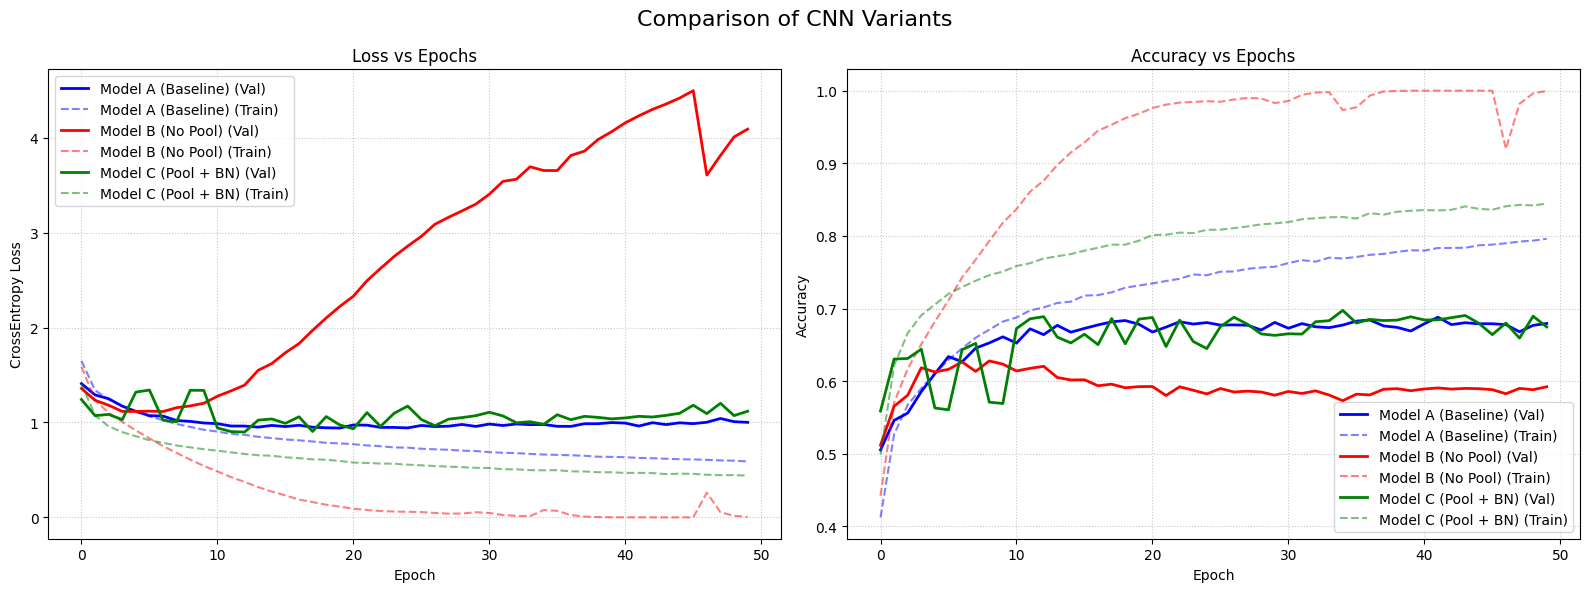

In [63]:
df_summary = pd.DataFrame(summary_table_data)
display(df_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Comparison of CNN Variants", fontsize=16)

colors = ['blue', 'red', 'green']
for (name, hist), color in zip(experiment_results.items(), colors):
    axes[0].plot(hist['val_loss'], label=f"{name} (Val)", color=color, linewidth=2)
    axes[0].plot(hist['train_loss'], label=f"{name} (Train)", color=color, linestyle='--', alpha=0.5)
    
    axes[1].plot(hist['val_acc'], label=f"{name} (Val)", color=color, linewidth=2)
    axes[1].plot(hist['train_acc'], label=f"{name} (Train)", color=color, linestyle='--', alpha=0.5)

axes[0].set_title("Loss vs Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend()
axes[0].grid(True, linestyle=":", alpha=0.7)

axes[1].set_title("Accuracy vs Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, linestyle=":", alpha=0.7)

plt.tight_layout()
plt.show()

1. What pooling changes in the network?
    Zdecydowanie stabilnieszy trening, nie aż tak poważny overfitting.
2. Whether pooling reduces computation?
    Niby mniej parametrów, ale zdecydowanie więcej czasu z pool'em
3. Whether removing pooling makes the model harder to train?
    Z tego co pokazują wykresy to nie.
4. Whether BatchNorm improves convergence?
    Bez BatchNorma trening wydaje sie być stabilniejszy.
5. Whether BatchNorm significantly changes final performance in your experiment?
    Wyniki ma porónwywalne do Baseline na walidacyjnym zbiorze danych.